In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from collections import defaultdict


# Preprocessing

In [ ]:


# fetch dataset
df = pd.read_csv('Myocardial infarction complications Database.csv')

#Drop ID
df = df.drop(columns=['ID'])

#Defining Alive or Lethal Outcome
df['Major_Complication'] = df['LET_IS'].apply(lambda x: 0 if x == 0 else 1)

X = df.drop(columns=['LET_IS', 'Major_Complication'])   # remove original multi-class cause column
y = df['Major_Complication']


# # data (as pandas dataframes)
# X = df.drop('LET_IS', axis =1 )
# y = df['LET_IS'] #determines lethal condition

X


,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,DLIT_AG,...,PREDS_TAH,JELUD_TAH,FIBR_JELUD,A_V_BLOK,OTEK_LANC,RAZRIV,DRESSLER,ZSN,REC_IM,P_IM_STEN
0,77.0,1,2.0,1.0,1.0,2.0,NaN,3.0,0.0,7.0,...,0,0,0,0,0,0,0,0,0,0
1,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,52.0,1,0.0,0.0,0.0,2.0,NaN,2.0,0.0,2.0,...,0,0,0,0,0,0,0,0,0,0
3,68.0,0,0.0,0.0,0.0,2.0,NaN,2.0,0.0,3.0,...,0,0,0,0,0,0,0,1,0,0
4,60.0,1,0.0,0.0,0.0,2.0,NaN,3.0,0.0,7.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1695,77.0,0,0.0,4.0,2.0,1.0,NaN,2.0,0.0,7.0,...,0,0,0,1,0,1,0,0,0,0
1696,70.0,0,0.0,6.0,2.0,1.0,NaN,2.0,0.0,7.0,...,0,0,0,0,0,0,0,0,0,0
1697,55.0,1,3.0,6.0,2.0,2.0,NaN,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,1,0
1698,79.0,0,2.0,2.0,2.0,1.0,NaN,2.0,0.0,7.0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
# finding the total amount of missing data
total_missing = df.isnull().sum().sum()
print(total_missing)

15974


In [ ]:
y

,Major_Complication
0,0
1,0
2,0
3,0
4,0
...,...
1695,1
1696,1
1697,1
1698,1


In [ ]:
X.info

<bound method DataFrame.info of        AGE  SEX  INF_ANAM  STENOK_AN  FK_STENOK  IBS_POST  IBS_NASL   GB  \
0     77.0    1       2.0        1.0        1.0       2.0       NaN  3.0   
1     55.0    1       1.0        0.0        0.0       0.0       0.0  0.0   
2     52.0    1       0.0        0.0        0.0       2.0       NaN  2.0   
3     68.0    0       0.0        0.0        0.0       2.0       NaN  2.0   
4     60.0    1       0.0        0.0        0.0       2.0       NaN  3.0   
...    ...  ...       ...        ...        ...       ...       ...  ...   
1695  77.0    0       0.0        4.0        2.0       1.0       NaN  2.0   
1696  70.0    0       0.0        6.0        2.0       1.0       NaN  2.0   
1697  55.0    1       3.0        6.0        2.0       2.0       NaN  0.0   
1698  79.0    0       2.0        2.0        2.0       1.0       NaN  2.0   
1699  63.0    1       2.0        NaN        NaN       NaN       NaN  2.0   

      SIM_GIPERT  DLIT_AG  ...  PREDS_TAH  JELUD_TAH  FIBR_JELUD  A_V_BLOK  \
0            0.0      7.0  ...          0          0           0         0   
1            0.0      0.0  ...          0          0           0         0   
2            0.0      2.0  ...          0          0           0         0   
3            0.0      3.0  ...          0          0           0         0   
4            0.0      7.0  ...          0          0           0         0   
...          ...      ...  ...        ...        ...         ...       ...   
1695         0.0      7.0  ...          0          0           0         1   
1696         0.0      7.0  ...          0          0           0         0   
1697         0.0      0.0  ...          0          0           0         0   
1698         0.0      7.0  ...          0          0           0         0   
1699         0.0      NaN  ...          0          0           0         0   

      OTEK_LANC  RAZRIV  DRESSLER  ZSN  REC_IM  P_IM_STEN  
0             0       0         0    0       0          0  
1             0       0         0    0       0          0  
2             0       0         0    0       0          0  
3             0       0         0    1       0          0  
4             0       0         0    0       0          0  
...         ...     ...       ...  ...     ...        ...  
1695          0       1         0    0       0          0  
1696          0       0         0    0       0          0  
1697          0       0         0    0       1          0  
1698          1       0         0    0       0          0  
1699          0       0         0    0       0          0  

[1700 rows x 122 columns]>

In [ ]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1700 entries, 0 to 1699
Series name: Major_Complication
Non-Null Count  Dtype
--------------  -----
1700 non-null   int64
dtypes: int64(1)
memory usage: 13.4 KB


In [ ]:
X.isnull().sum()

,0
AGE,8
SEX,0
INF_ANAM,4
STENOK_AN,106
FK_STENOK,73
...,...
RAZRIV,0
DRESSLER,0
ZSN,0
REC_IM,0


In [ ]:
X = pd.DataFrame(X)
y = pd.DataFrame(y)


In [ ]:
y.value_counts()

,count
Major_Complication,
0,1429
1,271


# Preprocessing cont.

In [ ]:
print(y.columns)

Index(['Major_Complication'], dtype='object')


In [ ]:
# from sklearn.preprocessing import OneHotEncoder # this will help encode categorical data
from sklearn.impute import SimpleImputer # this will help solve missing values

# making a copy of the features dataset / extracting the dependent varaible
df_features = X.copy()
df_target = y['Major_Complication']

# Identifying column value type
numeric_cols = df_features.select_dtypes(include = ["int64" , "float64"]).columns
categroical_cols = df_features.select_dtypes(include = ["object", "category"]).columns

print(numeric_cols)

Index(['AGE', 'SEX', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'IBS_POST',
       'IBS_NASL', 'GB', 'SIM_GIPERT', 'DLIT_AG',
       ...
       'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC',
       'RAZRIV', 'DRESSLER', 'ZSN', 'REC_IM', 'P_IM_STEN'],
      dtype='object', length=122)


In [ ]:
print(categroical_cols)


Index([], dtype='object')


In [ ]:
num_imputer = SimpleImputer(strategy="median") #replaces missing values with median
df_features[numeric_cols] = num_imputer.fit_transform(df_features[numeric_cols])

In [ ]:
import math

In [ ]:
df_features

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,DLIT_AG,...,PREDS_TAH,JELUD_TAH,FIBR_JELUD,A_V_BLOK,OTEK_LANC,RAZRIV,DRESSLER,ZSN,REC_IM,P_IM_STEN
0,77.0,1.0,2.0,1.0,1.0,2.0,0.0,3.0,0.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,55.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,52.0,1.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,68.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,60.0,1.0,0.0,0.0,0.0,2.0,0.0,3.0,0.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1695,77.0,0.0,0.0,4.0,2.0,1.0,0.0,2.0,0.0,7.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1696,70.0,0.0,0.0,6.0,2.0,1.0,0.0,2.0,0.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1697,55.0,1.0,3.0,6.0,2.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1698,79.0,0.0,2.0,2.0,2.0,1.0,0.0,2.0,0.0,7.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_features['IBS_NASL'].value_counts()


,count
IBS_NASL,
0.0,1673
1.0,27


In [ ]:
#dropping missing values
df_features = df_features.fillna(0) #Binary values, some zeroes are considered NaN
df_target = [x for x in df_target if x is not None]

In [ ]:
pd.Series(df_target).isnull().sum()

np.int64(0)

In [ ]:
df_features.shape

(1700, 122)

# Exploratory Data Analysis (with visualizations)



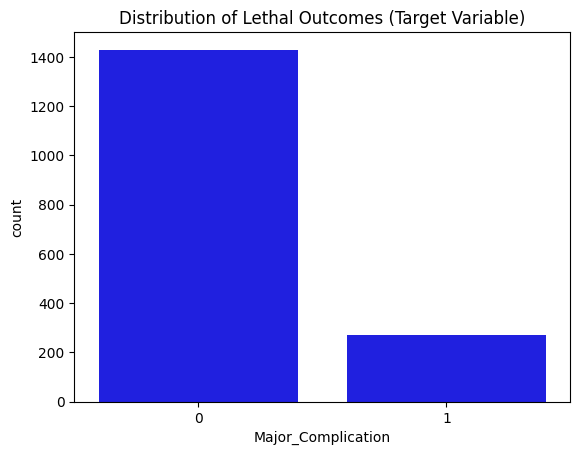

In [ ]:
# showing distribution of target variable
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data = df, x = 'Major_Complication', color = 'blue')
plt.title('Distribution of Lethal Outcomes (Target Variable)')

plt.show()

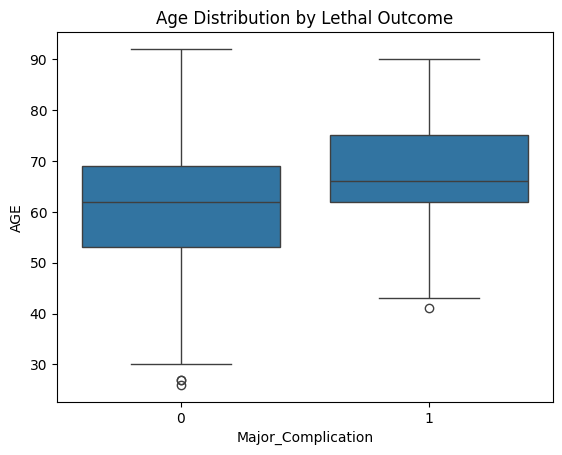

In [ ]:
# Observing 'Age' distribution by lethal outcome with a boxplot

sns.boxplot(data = df, x = 'Major_Complication', y = 'AGE')
plt.title('Age Distribution by Lethal Outcome')
plt.show()


***We have converted columns values into numeric values***
***We removed missing values by replacing NaN with the mode***
***Confirmed that there are no categorical values***

--> Now we split the data to do filtering and decsion tree

In [ ]:
# revert back to X,y format
X = df_features
y = df_target

# Train/test: 80/20 (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify = y, random_state=42)

| Measure                               | Use case (target type / feature type)                                           | When to use / Notes                                                                                                                                                                                        |
| ------------------------------------- | ------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Variance Thresholding**             | Any target and Any feature type (especially numeric) | Use this when you want to remove features that have little to no variation — e.g., nearly constant features across samples. These provide little information for modelling.        |
| **Correlation Coefficient (Pearson)** | Continuous target / Continuous features                                         | Use this when you have numeric features and a numeric target, and you assume linear relationships. Drop features whose absolute correlation with the target is below a threshold.  |
| **Chi-Square (χ²) Test**              | Categorical target / Categorical features                                       | Use this when both your features and target are categorical (or discrete). It tests whether the feature and target are independent (so low χ² → less useful).
|
| **Mutual Information (MI)**           | Any target type / Any feature type                                              | Use this when you suspect non-linear dependencies between features and the target. MI captures more general relationships than just linear correlation. |


#I'm using Mutual information for Feature Selection

In [ ]:
from sklearn.feature_selection import SelectKBest, SelectPercentile, VarianceThreshold, chi2, mutual_info_classif, mutual_info_regression

# Initialize and fit SelectKBest
selector = SelectKBest(mutual_info_classif, k=15) #chooses top 15 best features

# Filtering training data only
X_train_new = selector.fit_transform(X_train,y_train)

# Apply same transformation to test data
X_test_new = selector.transform(X_test)

In [ ]:
# getting the boolean mask that indicates which features are selected
# this line retrives a boolean array (mask) from the selector object, where each element is True
# if the corresponding feature in the original dataset X was selected by SelectKBest, and False otherwise.


# Filtering training data only
mask = selector.get_support()
mask

array([False,  True, False, False,  True, False, False, False, False,
       False,  True, False, False, False, False, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
        True, False,  True, False, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
        True,  True, False,  True,  True])

In [ ]:
# now we extract the feature names from the original training Dataframe
# Here, the boolean array mask is used to filter the columns of the original DataFrame X,
# extracting the names of the features that were selected by SelectKBest.
# These feature names are stored in selected_features

selected_features = X_train.columns[mask]

# # print original and selected feature names
# print("Original features:", X_train.columns.tolist())
# print("Selected features:", selected_features.tolist())

In [ ]:
selected_features

Index(['SEX', 'FK_STENOK', 'ZSN_A', 'nr_08', 'S_AD_ORIT', 'D_AD_ORIT',
       'K_SH_POST', 'ritm_ecg_p_01', 'L_BLOOD', 'R_AB_1_n', 'ASP_S_n',
       'RAZRIV', 'DRESSLER', 'REC_IM', 'P_IM_STEN'],
      dtype='object')

In [ ]:
print("Shape of X_train:", X_train_new.shape)

Shape of X_train: (1360, 15)


In [ ]:
X_train_new_df = pd.DataFrame(X_train_new, columns = selected_features)
X_test_new_df = pd.DataFrame(X_test_new, columns = selected_features)

In [ ]:
X_test_new_df

,SEX,FK_STENOK,ZSN_A,nr_08,S_AD_ORIT,D_AD_ORIT,K_SH_POST,ritm_ecg_p_01,L_BLOOD,R_AB_1_n,ASP_S_n,RAZRIV,DRESSLER,REC_IM,P_IM_STEN
0,1.0,0.0,0.0,0.0,130.0,80.0,0.0,1.0,6.1,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,3.0,0.0,0.0,110.0,70.0,0.0,0.0,8.3,1.0,1.0,0.0,0.0,0.0,0.0
2,1.0,2.0,0.0,0.0,180.0,90.0,0.0,1.0,6.9,0.0,1.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,180.0,110.0,0.0,1.0,7.3,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,2.0,0.0,0.0,200.0,110.0,0.0,1.0,12.9,2.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,1.0,2.0,0.0,0.0,130.0,80.0,0.0,1.0,12.0,0.0,1.0,0.0,0.0,0.0,0.0
336,0.0,2.0,1.0,0.0,140.0,90.0,0.0,0.0,10.7,0.0,1.0,0.0,0.0,0.0,0.0
337,0.0,2.0,0.0,0.0,140.0,80.0,0.0,1.0,6.7,0.0,0.0,0.0,0.0,0.0,0.0
338,1.0,2.0,2.0,0.0,140.0,70.0,0.0,1.0,8.1,0.0,0.0,0.0,0.0,0.0,0.0


# Begin Decision Tree Classification

In [ ]:
# Setup and stratified train/test split

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# the data is currently in list form, so we need to change them arrays

X_train_new = np.array(X_train_new)
X_test_new = np.array(X_test_new)
y_train = np.array(y_train)
y_test = np.array(y_test)


# Training and Testing data shape
print('Train:', X_train_new.shape, y_train.shape)
print('Test:', X_test_new.shape, y_test.shape)

Train: (1360, 15) (1360,)
Test: (340, 15) (340,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# building the decision tree
dt_model = DecisionTreeClassifier(criterion = 'entropy')

# fit the tree to the training dataset
dt_model.fit(X_train_new, y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
# plot decision tree
from sklearn import tree

fig, ax = plt.subplots(figsize=(40,40), dpi = 300)
tree.plot_tree(dt_model, ax = ax , feature_names = selected_features, class_names = ['Alive', 'Lethal'], filled =True, fontsize=10, max_depth =5)
plt.show()



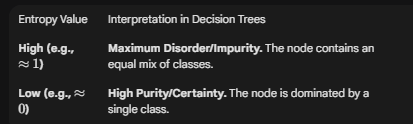

Train score 0.9985294117647059
Test score 0.8264705882352941
Confusion Matrix:
 [[252  34]
 [ 25  29]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.90       286
           1       0.46      0.54      0.50        54

    accuracy                           0.83       340
   macro avg       0.69      0.71      0.70       340
weighted avg       0.84      0.83      0.83       340



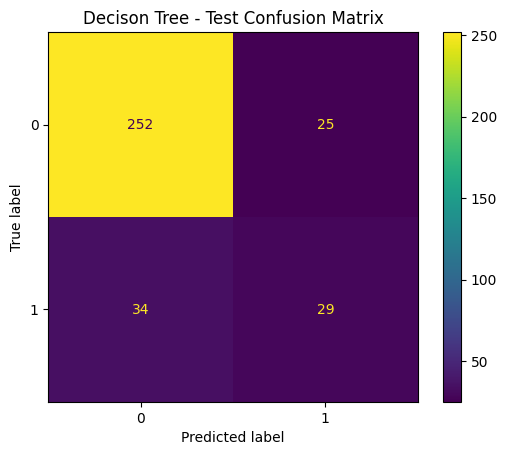

In [ ]:
from sklearn.preprocessing import StandardScaler # to standardize the features
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay
import seaborn as sns

y_train_pred = dt_model.predict(X_train_new)
y_test_pred = dt_model.predict(X_test_new)

print(f'Train score {accuracy_score(y_train_pred, y_train)}')
print(f'Test score {accuracy_score(y_test_pred, y_test)}')
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))


# # cfsm_1=ConfusionMatrixDisplay(confusion_matrix(y_train_pred,y_train))
# plt.title('Decison Tree Confusion Matrix')
# cfsm_2=ConfusionMatrixDisplay(confusion_matrix(y_test_pred,y_test))
# # cfsm_1.plot()
# cfsm_2.plot()

ConfusionMatrixDisplay(confusion_matrix(y_test_pred,y_test)).plot()
plt.title('Decison Tree - Test Confusion Matrix')
plt.show()

# Post Pruning

### Post pruning techniques

There are several post pruning techniques. Cost complexity pruning is one of the important among them.

Cost Complexity Pruning
Decision trees can easily overfit. One way to avoid it is to limit the growth of trees by setting constrains. We can limit parameters like max_depth , min_samples etc. But a most effective way is to use post pruning methods like **cost complexity pruning**. ***This helps to improve test accuracy and get a better model.***

**Cost complexity pruning** is all about finding the right parameter for alpha. We will get the alpha values for this tree and will check the accuracy with the pruned trees.

***Alpha (α) in cost-complexity pruning is the penalty term that controls how much you “punish” a deep, complicated decision tree.***

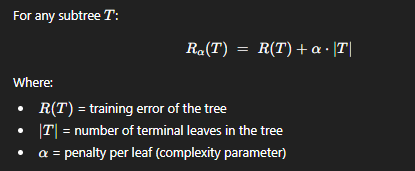

In [ ]:
path = dt_model.cost_complexity_pruning_path(X_train_new, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
print(ccp_alphas)

[0.         0.00091552 0.00098039 0.00111013 0.00118989 0.00132707
 0.00133749 0.00134482 0.00136512 0.00143387 0.00146041 0.00147059
 0.00147059 0.00147059 0.00147059 0.00152974 0.00162052 0.00162561
 0.00164835 0.00166519 0.00171418 0.00171478 0.00175694 0.00178316
 0.00178484 0.00178484 0.0018521  0.00189573 0.00191895 0.00194359
 0.00196645 0.00197791 0.00198406 0.00199077 0.00202062 0.00202565
 0.00202565 0.00203244 0.00206559 0.00208118 0.00209437 0.00211702
 0.00213239 0.0021507  0.00223377 0.0023494  0.00236026 0.00236089
 0.00238611 0.00238611 0.00244603 0.00245951 0.00250006 0.00250417
 0.00252511 0.00254957 0.00261191 0.0027008  0.00270508 0.00275119
 0.00279432 0.0028451  0.00285192 0.00296149 0.00324446 0.00328772
 0.00329146 0.00344946 0.00356929 0.00377397 0.00405131 0.00426953
 0.00429112 0.00442891 0.00481228 0.00528861 0.00646123 0.00731682
 0.00882136 0.00903913 0.01354381 0.01824218 0.02547607 0.07107415
 0.09214609]


- The code calls a method on a decision tree classifier (`model`) to determine the effective alpha values for pruning the tree to avoid overfitting.
- It extracts these alpha values and the related impurity scores from the training data (`x_train`, `y_train`).
- Then, it prints the alpha values, which are used to balance tree complexity and fit to the data.

#### Signficance of `Alpha`
* Alpha in `ccp_alphas` guides the pruning of the decision tree to prevent overfitting.
* A higher alpha value simplifies the model by removing less important branches.
* Choosing the optimal alpha can balance model complexity and accuracy.

In [ ]:
# For each alpha we will append our model to a list
models = []
for ccp_alpha in ccp_alphas:
  model = tree.DecisionTreeClassifier(random_state=42, ccp_alpha = ccp_alpha)
  model.fit(X_train_new, y_train)
  models.append(model)

This code snippet iterates over a range of alpha values (obtained from cost complexity pruning) and for each alpha, it creates, trains, and stores a separate decision tree model with that specific pruning level into a list called `models`. The `random_state=0` ensures reproducibility of the model training process.

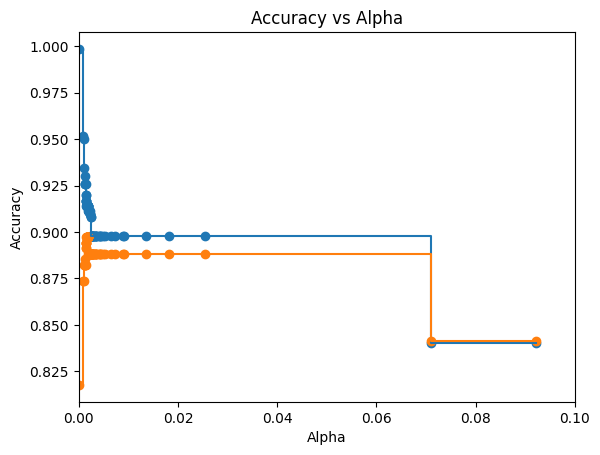

In [ ]:
train_acc = []
test_acc = []

# The code iterates through trained models, predicting
# and storing their accuracy on both training and testing data.
# It uses scatter plots to show individual accuracies for each alpha value.
# Step plots connect accuracy points to visualize the trend as model complexity changes.
# The resulting graph, titled 'Accuracy vs Alpha', helps identify
# the optimal balance between model simplicity and accuracy.

for m in models:
  y_train_pred = m.predict(X_train_new)
  y_test_pred = m.predict(X_test_new)
  train_acc.append(accuracy_score(y_train_pred, y_train))
  test_acc.append(accuracy_score(y_test_pred, y_test))


plt.scatter(ccp_alphas, train_acc)
plt.scatter(ccp_alphas, test_acc)
plt.plot(ccp_alphas, train_acc, label='train_accuracy', drawstyle = 'steps-post')
plt.plot(ccp_alphas, test_acc, label = 'test_accuracy', drawstyle = 'steps-post')

plt.legend
plt.title('Accuracy vs Alpha')
plt.xlabel('Alpha')
plt.xlim(0.0, 0.1) # Display alpha values from 0.0 to 0.05
plt.ylabel('Accuracy')
plt.show()

To determine the optimal alpha value from the plot generated by the above code, you would typically look for the value of ccp_alpha where the test accuracy is maximized or where the test accuracy begins to decrease, indicating overfitting is starting to be avoided.
- Look for the highest point on the test accuracy line; this is where the model is most accurate on new data.
- Pick the alpha value at this peak or just after, where test accuracy stays pretty much the same and doesn't drop off, to keep the model simple and effective.

In [ ]:
model.fit(X_train_new, y_train)
y_train_pred = model.predict(X_train_new)
y_test_pred = model.predict(X_test_new)

print(f'Train score {accuracy_score(y_train_pred, y_train)}')
print(f'Test score {accuracy_score(y_test_pred, y_test)}')


Train score 0.8404411764705882
Test score 0.8411764705882353


**Implement CCP pruning with cross validation**

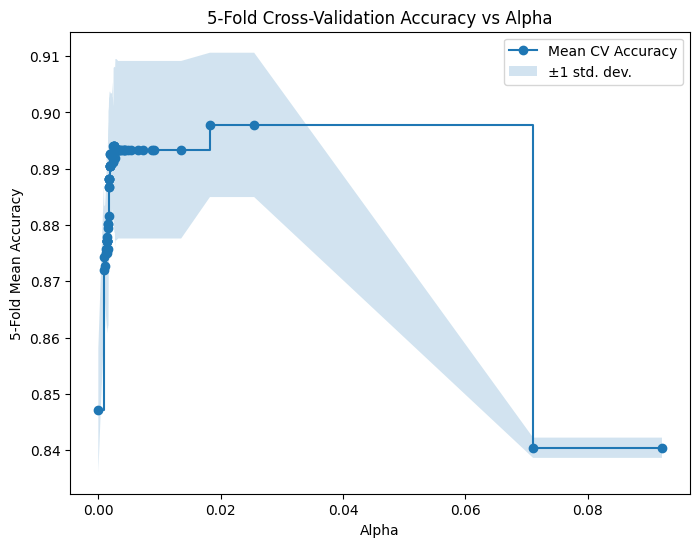

In [ ]:
cv_mean_acc = []
cv_std_acc = []

# Perform 5-fold cross-validation for each alpha
for ccp_alpha in ccp_alphas:
    model = tree.DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    # 5-fold CV using training data
    scores = cross_val_score(model, X_train_new, y_train, cv=5, scoring='accuracy')
    cv_mean_acc.append(scores.mean())
    cv_std_acc.append(scores.std())

plt.figure(figsize=(8, 6))
plt.plot(ccp_alphas, cv_mean_acc, marker='o', drawstyle="steps-post", label="Mean CV Accuracy")
plt.fill_between(ccp_alphas,
                 np.array(cv_mean_acc) - np.array(cv_std_acc),
                 np.array(cv_mean_acc) + np.array(cv_std_acc),
                 alpha=0.2, label='±1 std. dev.')
plt.xlabel("Alpha")
plt.ylabel("5-Fold Mean Accuracy")
plt.title("5-Fold Cross-Validation Accuracy vs Alpha")
plt.legend()
plt.show()

In [ ]:
# choosing the best alpha with the best mean CV accuracy
optimal_alpha = ccp_alphas[np.argmax(cv_mean_acc)]
print(f"Optimal alpha from 5-fold CV: {optimal_alpha:.4f}")

# train the final model with the best alpha
final_model = tree.DecisionTreeClassifier(random_state = 42, ccp_alpha = optimal_alpha)
final_model.fit(X_train_new, y_train)
y_train_pred = final_model.predict(X_train_new)
y_test_pred = final_model.predict(X_test_new)

print(f"Train Accuracy: {accuracy_score(y_train_pred, y_train)}")
print(f"Test Accuracy: {accuracy_score(y_test_pred, y_test)}")

Optimal alpha from 5-fold CV: 0.0182
Train Accuracy: 0.8977941176470589
Test Accuracy: 0.888235294117647


Post-pruned DT Test Accuracy: 0.8882

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94       286
           1       0.94      0.31      0.47        54

    accuracy                           0.89       340
   macro avg       0.91      0.66      0.70       340
weighted avg       0.89      0.89      0.86       340



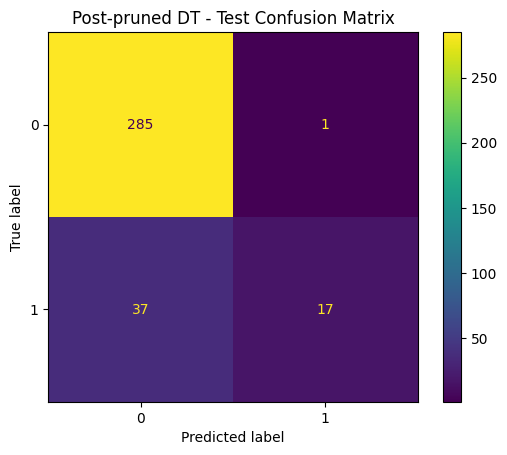

In [ ]:
# Showing the final confusion matrix after using post pruning and cross validation

# Test set predictions
test_pred = final_model.predict(X_test_new)
test_acc = accuracy_score(y_test, test_pred)
print(f"Post-pruned DT Test Accuracy: {test_acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred)).plot()
plt.title("Post-pruned DT - Test Confusion Matrix")
plt.show()

# # Complete dataset predictions
# # Apply the same feature selection to the full X dataset
# X_full_selected = selector.transform(X)
# full_pred = final_model.predict(X_full_selected)
# full_acc = accuracy_score(y, full_pred)
# print(f"Post-pruned DT Complete Dataset Accuracy: {full_acc:.4f}")

# ConfusionMatrixDisplay(confusion_matrix(y, full_pred)).plot()
# plt.title("Post-pruned DT - Complete Data Confusion Matrix")
# plt.show()

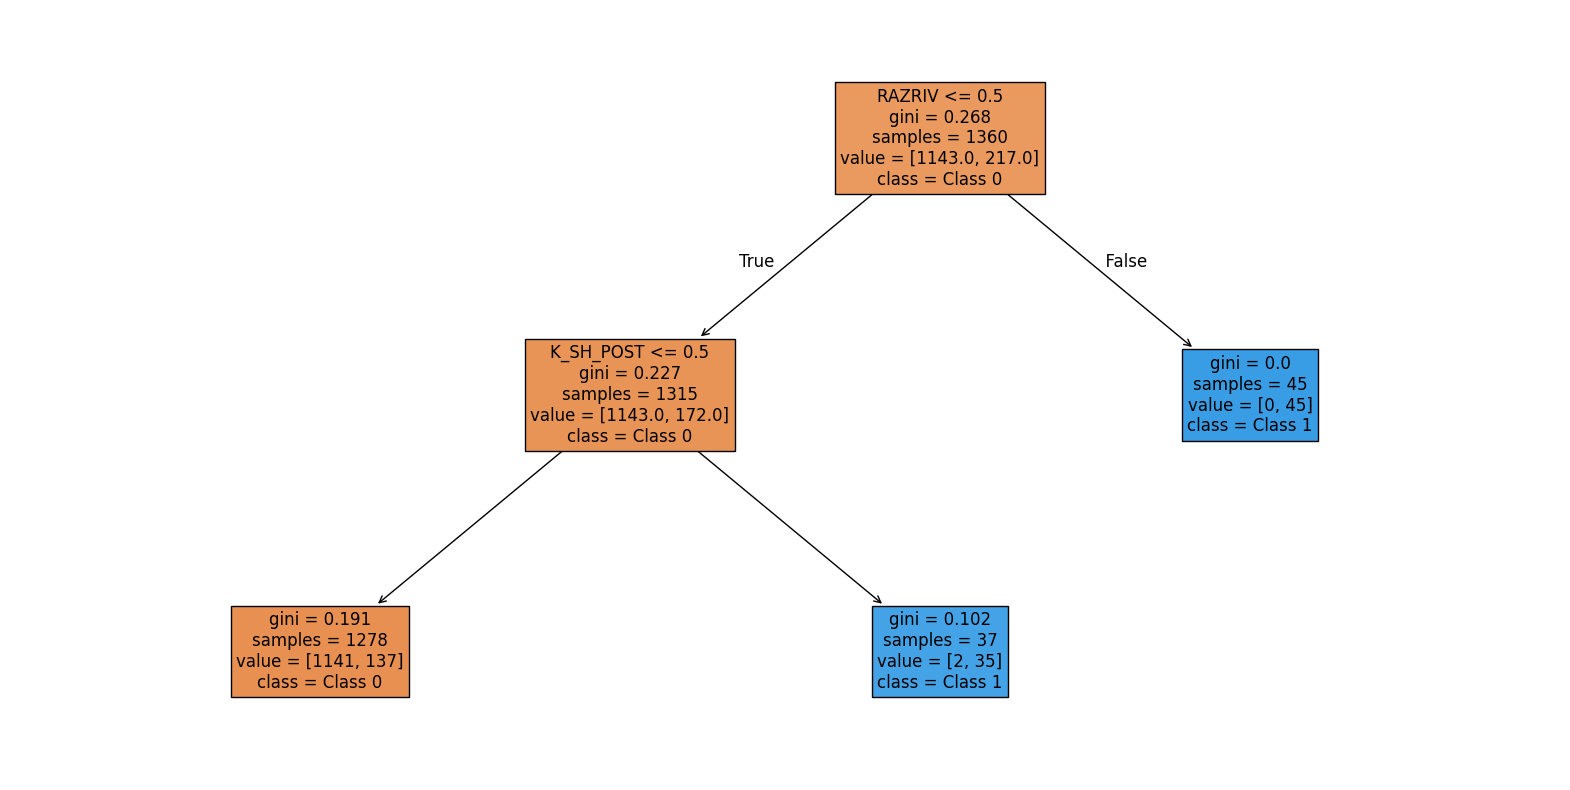

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np

# Plot Decision Tree (clean formatted version)
plt.figure(figsize=(20,10))

# Dynamically get feature names from selected features
feature_names = selected_features

# Dynamically get class names from y_train
unique_classes = sorted(np.unique(y_train))
class_names = [f'Class {c}' for c in unique_classes]

plot_tree(
    final_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    fontsize=12
)

plt.show()


# Resampling the data using SMOTE to change the distribution of the positives and negatives. (hopefully to achieve higher accuracy)

#SMOTE using a Pipeline

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier

# Define the SMOTE object (using your desired ratio)
smote = SMOTE(sampling_strategy = 0.66, random_state = 42)

# Define the model you want to use
dt_model = DecisionTreeClassifier(random_state=42)

# Create the pipeline: (1) Apply SMOTE, (2) Train Decision Tree
pipeline = Pipeline(steps=[('smote', smote),
                           ('classifier', dt_model)])

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameters you want to search over for the Decision Tree
param_grid = {
    'classifier__max_depth': [3, 5, 7, 10, None],  # Max depth of the tree
    'classifier__min_samples_leaf': [1, 5, 10, 20] # Minimum samples required to be at a leaf node
}

# Set up the Grid Search with 5-fold Cross-Validation (cv=5)
# Use a suitable metric like 'f1_weighted' or 'roc_auc' for imbalanced data
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_weighted', # Better than accuracy for imbalanced data
    cv=5,
    n_jobs=-1
)

# The .fit() call is moved to the next cell to ensure proper execution before accessing best_estimator_.

# scoring='recall' force the computer to find the model that catches the most heart attacks, ignoring accuracy

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Run the search on the ORIGINAL (feature-selected, unresampled) training data
# The SMOTE step in the pipeline will handle resampling within each CV fold.
grid_search.fit(X_train_new, y_train)

# Get the best trained model (which is a Pipeline object)
best_model = grid_search.best_estimator_

# Make predictions on the UNSEEN test data (using X_test_new and y_test)
y_pred = best_model.predict(X_test_new)

# Print the Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Print a detailed report including Precision, Recall, and F1-score for each class
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[270  16]
 [ 27  27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93       286
           1       0.63      0.50      0.56        54

    accuracy                           0.87       340
   macro avg       0.77      0.72      0.74       340
weighted avg       0.86      0.87      0.87       340



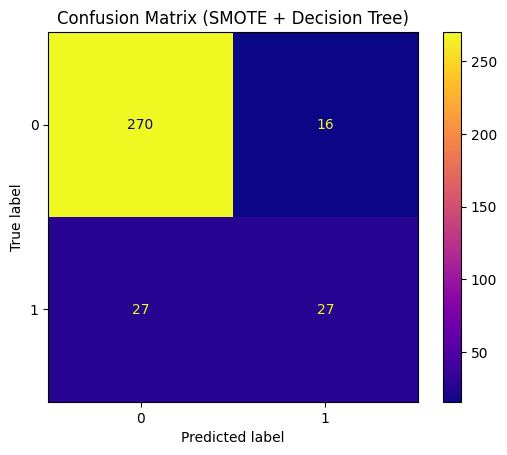

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# This function creates the plot using your actual results
# cmap='viridis' gives it that yellow/green/purple color scheme you showed
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='plasma',
    values_format='d' # 'd' ensures numbers are shown as integers (no decimals)
)

# Add a title
plt.title("Confusion Matrix (SMOTE + Decision Tree)")

# Display the plot
plt.show()


**Reading Confusion Matrix in Sklearn:**
| Actual \ Predicted | 0  | 1  |
|--------------------|----|----|
| 0                  | TN | FP |
| 1                  | FN | TP |


# APPROACH 2: Instead of using filtering for feature selection, we'll now use Random Forest then Decsision Tree Classificationto to see if we can get better predictions.

- we will not be using SMOTE here because the randomforestclassfier has a parameter called class_weight = 'balanced', which is a common and effective technique for dealing with imbalanced data in tree-based models
- the parameter itself tells RandomForestClassifier to automatically adjust the weights inversely proportional to class frequencies. This means samples from the minority class are given a higher weight than samples from the majority class during training.

In [ ]:
 # uploading file again

df2 = pd.read_csv('Myocardial infarction complications Database.csv')

In [ ]:
# Defiining alive or major complication
df2['Major_Complication'] = df2["LET_IS"].apply(lambda x: 0 if x == 0 else 1)

# Dropping the ID column
df2 = df2.drop(columns = ['ID'])

In [ ]:
# handling missing values with for loops and if statement for ease

for col in df2.columns:
  if df2[col].dtype == 'float64' or df2[col].dtype == 'int64':
    df2[col] = df2[col].fillna(df2[col].median()) #for nonbinary variables we will replace missing values with the median
  else:
    df2[col] = df2[col].fillna(df2[col].mode())

In [ ]:
X = df2.drop(columns=['LET_IS', 'Major_Complication'])   # remove original multi-class cause column
y = df2['Major_Complication']

In [ ]:
y.value_counts()

,count
Major_Complication,
0,1429
1,271


In [ ]:
# train and test split the data
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [ ]:
# Implementing decision tree first

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

dt2 = DecisionTreeClassifier(
    criterion="gini",      # BEST for death prediction
    max_depth=None,            # allow full growth
    min_samples_leaf=10,       # PREVENT tiny leaves
    min_samples_split=20,      # stabilize splits
    class_weight="balanced",   # critical for DEATH class
    random_state=42
)
dt2.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=10,
                       min_samples_split=20, random_state=42)

Accuracy: 0.7647058823529411
Confusion Matrix:
 [[222  64]
 [ 16  38]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.78      0.85       286
           1       0.37      0.70      0.49        54

    accuracy                           0.76       340
   macro avg       0.65      0.74      0.67       340
weighted avg       0.84      0.76      0.79       340



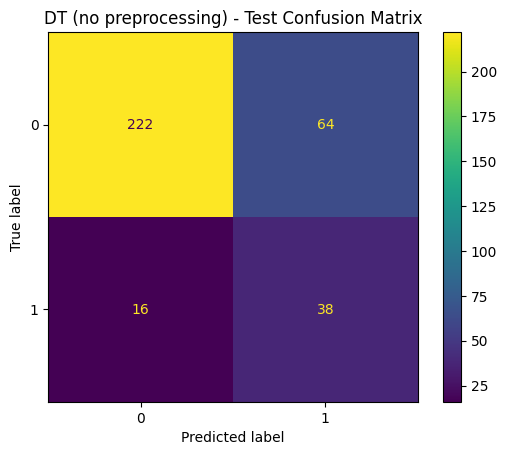

In [ ]:
# Test Decision Tree

y_pred = dt2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()
plt.title("DT (no preprocessing) - Test Confusion Matrix")
plt.show()


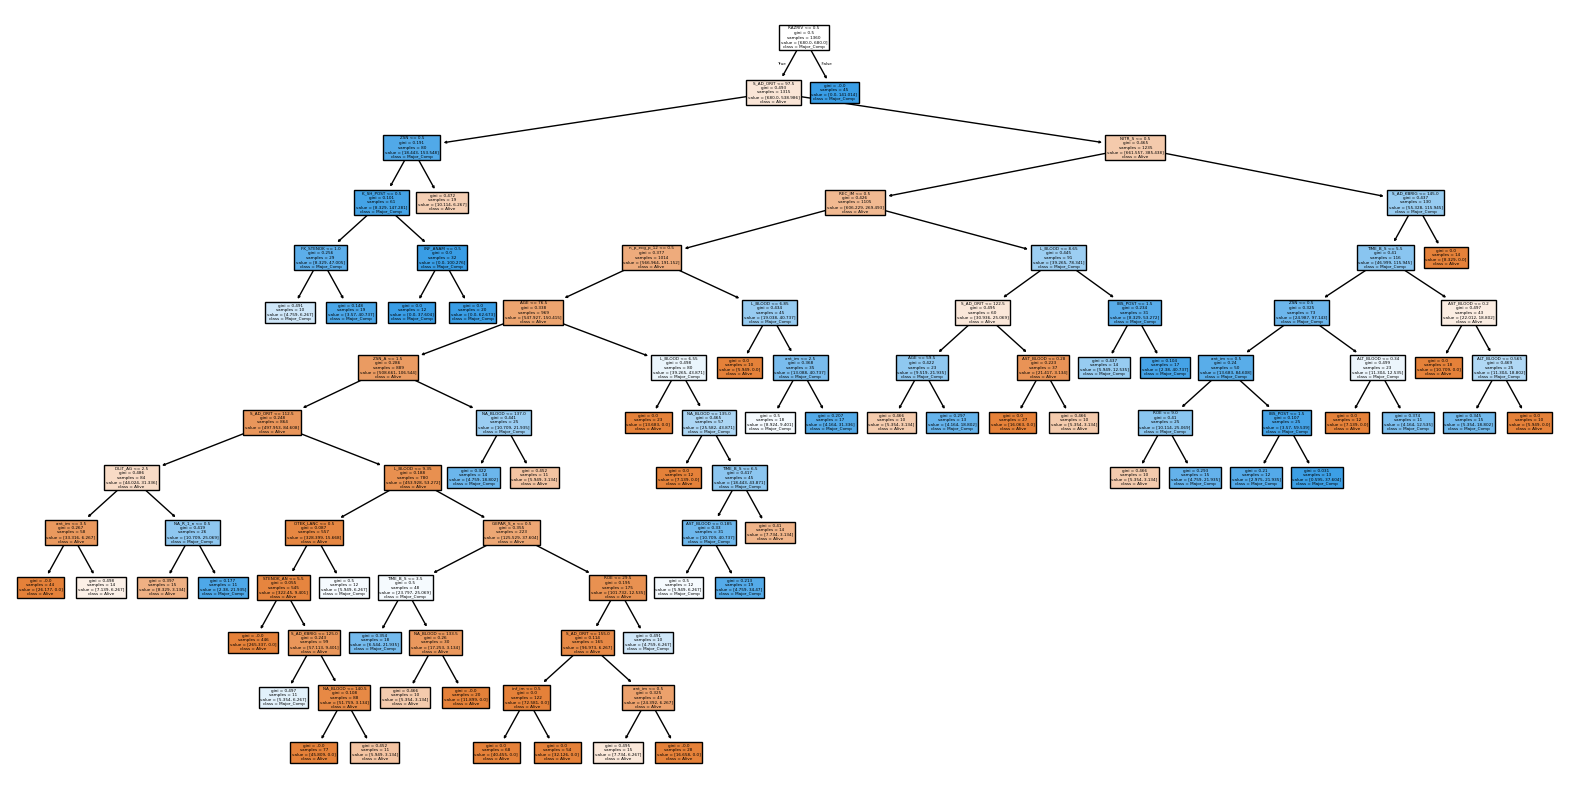

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

#Plot Decision Tree
plt.figure(figsize=(20,10))
plot_tree(dt2, feature_names=X.columns, class_names=['Alive','Major_Comp'], filled=True)
plt.show()


In [ ]:
# Now we are implementing Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Random forest training
rf = RandomForestClassifier(n_estimators = 300, #300 trees will be produced
                            max_depth = None, min_samples_leaf = 5, # a leaf node must contain 5 samples; it reduces overfitting bc leaves must represent enough data
                            class_weight = 'balanced', #this will RF will automatically adjust weights to account for class imbalance.
                            random_state = 42, n_jobs = -1 #this will use all CPU cores
                            )

More trees usually:

reduce variance (better generalization),

increase training time.

In [ ]:
# Fit random forest model

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
# now time to test the RF Model

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.9


In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf)
print("Classification Report\n:", classification_report(y_test, y_pred_rf))

Confusion Matrix:
 [[275  11]
 [ 23  31]]
Classification Report
:               precision    recall  f1-score   support

           0       0.92      0.96      0.94       286
           1       0.74      0.57      0.65        54

    accuracy                           0.90       340
   macro avg       0.83      0.77      0.79       340
weighted avg       0.89      0.90      0.89       340



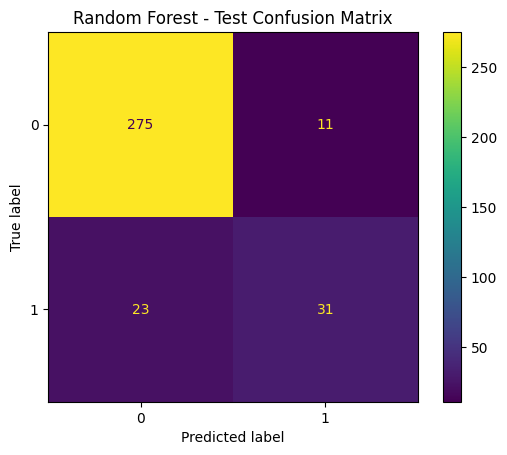

In [ ]:
disp_rf_cm = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf_cm.plot()
plt.title("Random Forest - Test Confusion Matrix")
plt.show()

           feature  importance
0              AGE    0.071411
35       S_AD_ORIT    0.066188
90        TIME_B_S    0.060568
117         RAZRIV    0.060278
88         L_BLOOD    0.055951
36       D_AD_ORIT    0.045974
3        STENOK_AN    0.035012
43          ant_im    0.029724
48   ritm_ecg_p_01    0.028709
89             ROE    0.027762
38       K_SH_POST    0.023568
98        NA_R_1_n    0.021079
9          DLIT_AG    0.021072
97          NITR_S    0.020779
82         K_BLOOD    0.019317
84        NA_BLOOD    0.019309
85       ALT_BLOOD    0.019211
10           ZSN_A    0.018996
86       AST_BLOOD    0.018632
4        FK_STENOK    0.017993


<Figure size 1000x600 with 0 Axes>

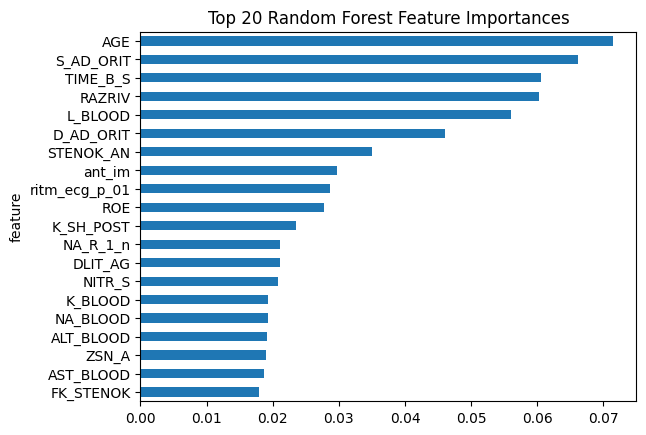

In [ ]:
# Identifying Top 20 Important features identified by
if_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance':rf.feature_importances_}).sort_values(by = 'importance', ascending = False)


print(if_rf.head(20))


# plotting important features for better visuals
plt.figure(figsize = (10,6))
if_rf.head(20).plot(kind='barh', x  = 'feature', y = 'importance', legend = False)
plt.title("Top 20 Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()

**Intrinsic Mechanism of Random Forest Classificaiton(Feature Selection by Default)**

**Because of the random feature subset selection at each split:**

Best Features are Chosen: Each tree naturally selects the most relevant feature from its random subset to make the split, which leads to better-performing trees.

**Irrelevant Features are Ignored:** Features that are uninformative or pure noise will rarely be chosen as the best split criterion in any individual tree. When they are chosen, they won't significantly reduce impurity (Gini impurity or variance), and thus they are effectively ignored by the model ensemble's overall prediction.